# Workbench Compilation Pipeline

This deep dive focuses on the particulars of the Workbench compilation pipeline.  It will give a more detailed view of the different types of filters available to users during compilation, how filters process operations, and how the user can interact with the data collected by those filters during compilation.

## Compilation

At a high level, compilation is the process of transforming, analyzing, or translating the program.  Workbench performs all of these tasks through a set of software tools called _filters_. Each filter has a specific task, and by combining several filters together, Workbench can optimize, analyze and simulate programs capable of running on future quantum hardware.

The pipeline is designed to efficiently process different quantum programs and flexibly apply different compilation strategies.  You can instantiate, interact with, and access the compilation pipeline through the QPU object, described in the [tutorial on configuring program execution](../tutorials/Configuring-Execution.ipynb).  This deep dive will build up an understanding of the compilation pipeline from the operations that describe a quantum program, to the filters that process the operations, and finally the QPU that dispatches operations, manages the filter pipeline and collects information from the filters.

## Instructions

The instruction is the building block of the quantum programs.  Each instruction contains all the necessary information to fully execute a particular operation.  As such, it is the minimum component that our compilation pipeline needs to be able to handle.

In the example below, we show the instantiation of a QPU and a Qubits register, followed by a set of quantum operations on that register.  Then, we use the `get_instructions` method to print the stream of instructions added to the circuit from the QPU in the same format as the compilation pipeline receives them.

Operations in the circuit:
qc.reset(num_qubits=3)
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.x(target_mask=0x1)
qc.had(target_mask=0x3, condition_mask=0x4)
qc.z(target_mask=0x4, condition_mask=0x3, cond_xor_mask=0x2)
qc.read(target_mask=0x7, result=0, set_flag=2)



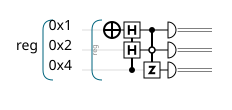

In [1]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3, filters=['>>buffer>>'])
qubits = Qubits(3, 'reg', qpu)

qubits[0].x()
qubits[0:2].had(cond=qubits[2])
qubits[2].z(cond=qubits[0] | ~qubits[1])
a = qubits.read()

instructions = qpu.get_instructions(format='asm')
print('Operations in the circuit:')
print(instructions)

qpu.draw()

The instruction describes the type of operation, denoted with `qc.<op_name>`, in this case, there are `x`, `had`, `z` and`read`-type quantum operations in this program. The target qubits for each quantum operation are denoted with a `target_mask` field. Additionally, these operations may have other information describing the control qubits of the operation in the `condition_mask` and `cond_xor_mask` fields.  Certain operations, like `read`, may have specific details that are exclusive to that type of operation. However, every quantum operation has information necessary to fully describe it for use in simulation, decomposition, or execution later on in the pipeline.

Notably, information about the flow of classical data is not included in the instruction stream. For example, the `read` instruction only denotes which Qubits register is being measured.

As seen in the above example, the stream of instructions contains more than just the quantum operations performed on the qubits.  The stream also includes book-keeping information like resetting the QPU and allocating the Qubits register. While not shown here, other non-quantum instructions include the start and ending of `compute` and `uncompute` Qubrick methods, errors and labels for drawing.  While not necessarily integral to the end result of the circuit, it is important metadata that be used by filters such as quantum resource estimation filters.

> The output of `get_instructions` can also act as low-level Workbench code when applied directly to a QPU.

## Filters

Where instructions are the building blocks of programs, filters are the building blocks of the compilation pipeline.  A _filter_ is a piece of software designed to perform one specific optimization, transformation, analysis or utility function on the instructions describing the program.  It accepts and processes instructions, analyzes those instructions, then generates a transformed set of instructions or emits the same set of instructions while aggregating data to be used later.

The filter pipeline is built out of a linked list of filters. Each filter stores a reference to the next filter in the pipeline such that it can pass off instructions or requests for data through the filter pipeline to complete the compilation task.  The QPU holds a reference to the first filter in the pipeline and manages the initial flow of instructions into the pipeline.

A filter receives an instruction, or a list of instructions, from either the QPU or the previous filter. Then the filter performs the specified action on that batch of instructions.  It should be noted that this batch of instructions cannot be assumed to be the entire program, or even an entire Qubrick.  A filter must be able to operate on one instruction at a time, without knowledge of the context of the rest of the program.  If the filter needs this sort of context, it must do its own tracking and analysis of the instruction stream.

Following the completion of the filter's function, the filter emits the instructions to the next linked filter.

## Types of filters

Within the filter pipeline, not every filter is performing the same kind of task.  Workbench filters fall into four major categories.  Three of these categories generate information for the developer: simulation, analysis and utility filters. The fourth category is transformation, where the program is manipulated and optimized to fit the required format for a particular simulator or hardware.

This section will walk through the effects of each type of filter, how they change the program, and how the developer can interact with each filter type.

Below is an example program that only has the default filters: `buffer`, `witness` and `state-vector-sim`. The `buffer` filter captures the instructions that are output at the end of the program, the `witness` collections resource usage information, and the `state-vector-sim` simulates the program.  In this program, we apply a single Toffoli gate. We will use this as the basis for many of the following examples.

A comprehensive list of the available filters can be found in the [tutorial on configuring program execution](../tutorials/Configuring-Execution.ipynb).

Instructions without any filters:

qc.reset(num_qubits=3)
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.x(target_mask=0x4, condition_mask=0x3)



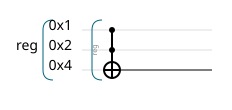

In [2]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)
reg = Qubits(3, 'reg', qpu)
reg[2].x(reg[:2])
instructions = qpu.get_instructions(format='asm')
print('Instructions without any filters:\n')
print(instructions)

qpu.draw()

### Transformation filters

The transformation filters process and directly change the instruction stream.  As a transformation filter receives operations, it performs some sort of analysis and determines whether the circuit needs to be changed.  This can be as simple as looking for a specific kind of gate and decomposing it, or can involve looking at a larger section of the program and rewriting those sections to be more efficient via a specific optimization.  An example of a transformation filter is the `single-control-filter` seen in the [Execution Model](./Execution-Model.ipynb) deep dive.

In the example below, the `toffoli-filter` is receiving operations in an instruction stream from the QPU. It is inspecting each instruction for a doubly-controlled X gate. If the operation does not match this description, it is directly emitted to the next filter, as it does not need to be changed.

However, if a matching instruction is found, instead of simply adding the operation to the instruction stream, the filter adds the decomposition of the Toffoli gate to the instruction stream.  The following filter receives this new version of the program, and will operate as if the Toffoli gate had been decomposed in the original program.

This can be seen in the example below, where our instruction stream is much longer following the application of the `toffoli-filter`. The stream no longer contains the doubly-controlled X gate, but instead, T, H and singly-controlled X gates.

Instruction with transformation filters:

qc.reset(num_qubits=3)
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.x(target_mask=0x0)
qc.had(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x2)
qc.t_inv(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x1)
qc.t(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x2)
qc.t_inv(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x1)
qc.t(target_mask=0x6)
qc.x(target_mask=0x2, condition_mask=0x1)
qc.had(target_mask=0x4)
qc.t(target_mask=0x1)
qc.t_inv(target_mask=0x2)
qc.x(target_mask=0x2, condition_mask=0x1)
qc.x(target_mask=0x0)



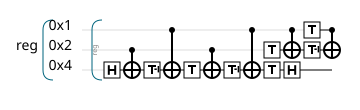

In [3]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3, filters=['>>toffoli-filter>>', '>>buffer>>'])
reg = Qubits(3, 'reg', qpu)
reg[2].x(reg[:2])
instructions = qpu.get_instructions(format='asm')
print('Instruction with transformation filters:\n')
print(instructions)

qpu.draw()

### Simulation filters

A simulation filter mimics a real quantum computer and maintains its own representation of the current state of the program.  Rather than altering the instruction stream, whenever the simulator receives an instruction from the previous filter, it analyzes the operation and changes the internal representation of the state of the program appropriately.  Then the simulation filters emits instructions to the next filter without changing them.

Simulation information is not readily available in the resulting instruction stream.  However, the data from simulators is made accessible through return values of the `read` method and debugging methods like `pull_state` which allow us to examine the state of the program at a given point (see the [tutorial on testing and debugging](../tutorials/Testing-Debugging.ipynb)).

A list of supported simulation filters can also be found in the [tutorial on configuring execution](../tutorials/Configuring-Execution.ipynb).

In the example below, our compilation pipeline only includes the `state-vector-sim` filter, and a `buffer`. We use the utility method `pull_state` to print the state vector before and after the gates are applied. These gates change the quantum state.  By examining the instruction stream, it is evident that the state vector simulator did not change the instructions in the stream. However, the internal state representation of the program is changed when we examine the output of `pull_state` before and after the gates are applied.

In [4]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3, filters=['>>state-vector-sim>>', '>>buffer>>'])
reg = Qubits(3, 'reg', qpu)

sim_filter = qpu.get_filter_by_name('>>state-vector-sim>>')

print('State vector before operations: ')
print(sim_filter.pull_state())
print()

reg[0].had()
reg[1:].x(reg[0])
instructions = qpu.get_instructions(format='asm')
print('Instruction with simulation filter:')
print(instructions)

print('State vector after operations: ')
print(sim_filter.pull_state())

State vector before operations: 
[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]

Instruction with simulation filter:
qc.reset(num_qubits=3)
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.had(target_mask=0x1)
qc.x(target_mask=0x6, condition_mask=0x1)

State vector after operations: 
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


### Analysis filters

Analysis filters are structured like simulation filters and are a subset of the utility filters mentioned in the [Execution Model deep dive](./Execution-Model.ipynb). As instructions are added to an analysis filter, it keeps track of the instructions added and updates a dictionary (or custom data structure) of metrics of interest. And, like the simulation filter, it does not change the instruction stream.  The results of the analysis filter are not accessed during compilation itself, but are instead used for later processing to perform tasks such as quantum resource estimation.  The information gathered during analysis can also be accessed through utility methods and attributes of the filter, such as the `witness` attribute of the `witness` filter.

In the following example, we show the `witness` filter processing the same instructions processed with the simulator earlier.  Using the `witness` filter, we examine the number of quantum operations in the circuit before and after the operations are applied to the Qubits register.  By using the utility `witness` attribute, we can see the increase in operation counts.  Once again, we notice that when we examine the resulting operations after processing by the `witness` filter, there has been no change in the instructions stream.

In [5]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.qre import resource_estimator

qpu = QPU(num_qubits=3, filters=['>>witness>>', '>>buffer>>'])
reg = Qubits(3, 'reg', qpu)

witness_filter = qpu.get_filter_by_name('>>witness>>')

print('Number of operations from witness before operations: ')
witness_costs = resource_estimator(qpu).resources(expanded=True)
print(witness_costs["total_num_ops"])

reg[0].had()
reg[1:].x(reg[0])
instructions = qpu.get_instructions(format='asm')
print('\nInstruction with Witness filter:')
print(instructions)

print('Number of operations from witness after operations: ')
witness_costs = resource_estimator(qpu).resources(expanded=True)
print(witness_costs['total_num_ops'])

Number of operations from witness before operations: 
0

Instruction with Witness filter:
qc.reset(num_qubits=3)
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.had(target_mask=0x1)
qc.x(target_mask=0x6, condition_mask=0x1)

Number of operations from witness after operations: 
2


While this is a simple example, the `witness` filter has access to many pieces of data about the quantum program that aid in generating resource estimates for future algorithm optimization.

### Utility filters

A utility filter is a catch-all categorization for a filter that does not change the program, but also does not perform direct analysis or simulation of the program.  Some examples of these filters are translation to a different circuit format like Qiskit or OpenQASM, or interfacing with external software. Similar to analysis filters, utility filters often generate data that will need to be accessed later on.  You will need to use methods of the filter object to get the data, similar to how we've done it in the witness filter example.

In the below example, we show how [the `qasm-export` filter](../tutorials/Exporting-to-OpenQASM.ipynb) processes the instruction stream and translates the Workbench instructions to an OpenQASM program.  Notice that we first query the QPU to find the `qasm-export` filter in the compilation pipeline by using the `get_filter_by_name` method. This returns the filter object, where we can directly use the `get_qasm_string` method to access the translated program.

In [6]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3, filters=['>>qasm-export>>', '>>buffer>>'])
reg = Qubits(3, 'reg', qpu)

qasm_export_filter = qpu.get_filter_by_name('>>qasm-export>>')

print('QASM String before operations added: ')
qasm_string = qasm_export_filter.get_qasm_string()
print(qasm_string)

reg[0].had()
qubits[1:].x(reg[0])

print('\nInstruction with QASM Exporter filter:')
print(instructions)

print('QASM String after operations added: ')
qasm_string = qasm_export_filter.get_qasm_string()
print(qasm_string)

QASM String before operations added: 
OPENQASM 3;
include "stdgates.inc";

qubit[3] q;

let reg_1 = q[0:3];

Instruction with QASM Exporter filter:
qc.reset(num_qubits=3)
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.had(target_mask=0x1)
qc.x(target_mask=0x6, condition_mask=0x1)

QASM String after operations added: 
OPENQASM 3;
include "stdgates.inc";

qubit[3] q;

let reg_2 = q[0:3];
h q[0];


Once again, we notice that the instructions in the program are not changed by applying this utility filter. But the OpenQASM program before and after the application of the quantum operations is changed.

## How filters process operations

Many of the filters described thus far are relatively simple. Every instruction maps to a specific action that does not require extra context about the surrounding circuit for processing.  However, compilation can often be more complicated than one-to-one instruction-to-action conversion. It may require future knowledge of the circuit to accurately rewrite or analyze parts of the program.  As such, not every filter immediately passes each instruction to the next filter in the pipeline after the initial processing.

Transformation filters rely on two main models of handling operations: "process and emit" and "process, store, and transform" models. Let's take a closer look at them.

### "Process and emit" model

This model doesn't require any context about the future components of the circuit. So, the filter can receive the instruction, analyze the operation, and immediately output it to the next filter.

The `toffoli-filter` we've seen before examines each quantum operation in the instruction stream and checks whether it is a Toffoli gate. If it is, it replaces the Toffoli instruction with the decomposition and adds that decomposition directly to the instruction stream. Below, we show the `toffoli-filter` in verbose mode.

In [7]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3, filters=['>>toffoli-filter>>', '>>buffer>>'])
reg = Qubits(3, 'reg', qpu)

toffoli_filter = qpu.get_filter_by_name('>>toffoli-filter>>')
toffoli_filter.verbosity = 1

print('Processing and emitting operations as they are received')

reg[0].had()
reg[2].x(reg[:2])

Processing and emitting operations as they are received
>>>>>>>>>>>>-------------------------------
>>toffoli-filter>> receiving:
qc.had(target_mask=0x1)

>>>>>>>>>>>>-------------------------------
>>toffoli-filter>> processing:
qc.had(target_mask=0x1)

>>>>>>>>>>>>-------------------------------
>>toffoli-filter>> emitting:
qc.had(target_mask=0x1)

>>>>>>>>>>>>-------------------------------
>>toffoli-filter>> receiving:
qc.x(target_mask=0x4, condition_mask=0x3)

>>>>>>>>>>>>-------------------------------
>>toffoli-filter>> processing:
qc.x(target_mask=0x4, condition_mask=0x3)

>>>>>>>>>>>>-------------------------------
>>toffoli-filter>> emitting:
qc.x(target_mask=0x0)
qc.had(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x2)
qc.t_inv(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x1)
qc.t(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x2)
qc.t_inv(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x1)
qc.t(target_mask=0x6)
qc.x(target_mask=0x2, conditi

Notice that for each operation, there is a trio of `receiving`, `processing` and `emitting` messages one after the other. In other words, the following filter in the pipeline gets immediate access to the set of operations after the `toffoli-filter` processes a particular set of instructions.

### "Process, store and transform" model

Some filters need to perform more complicated transformations. For example, the `window-filter` is a cancellation filter. Whenever this filter recognizes that two operations are inverses of each other and are adjacent to one another, it removes both operations from the instruction stream.  As a concrete example, if two X gates on qubit 3 were applied one after the other, they can be removed from the circuit as the second X gate is performing the inverse operation of the first X gate.

However, due to circuit construction, it may not be immediately obvious that an operation is immediately followed by its inverse. So, the `window-filter` cannot immediately process and emit instructions the same way as the `toffoli-filter`. The `window-filter` instead uses the following protocol:

1. Analyze the operation and check to see if it is the inverse for the most recent operations for each of the used qubits.
2. If there is no inverse, add it to a stored list in the filter.
3. If there is an inverse, remove the previous operation from the stored list and discard both the new operation and the old operation.
4. Repeat for each new operation added to the filter.

Notice that there is no natural point where the instructions are emitted to the next filter in the pipeline. This is because the filter needs as much context about the circuit as possible. Each cancellation opens up future opportunities, and so the filter stores as much information as it can before emitting the new instruction stream to the future filters. The next section will discuss when these instructions are emitted.

A verbose example using the window filter is shown below:

In [8]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.filter_machinery import WindowFilterBase

qpu = QPU(num_qubits=3, filters=[WindowFilterBase(name="window-filter"), '>>buffer>>'])
reg = Qubits(3, 'reg', qpu)

window_filter = qpu.get_filter_by_name('window-filter')
window_filter.verbosity = 1

print('Processing and storing operations, these are not emitted immediately:')

reg[0].had()
reg[2].x(reg[:2])
reg[2].x(reg[:2])
reg[0].had()
reg[0].x()

Processing and storing operations, these are not emitted immediately:
>>>>>>>>>>>>-------------------------------
window-filter receiving:
qc.had(target_mask=0x1)

>>>>>>>>>>>>-------------------------------
window-filter processing:
qc.had(target_mask=0x1)

>>>>>>>>>>>>-------------------------------
window-filter receiving:
qc.x(target_mask=0x4, condition_mask=0x3)

>>>>>>>>>>>>-------------------------------
window-filter processing:
qc.x(target_mask=0x4, condition_mask=0x3)

>>>>>>>>>>>>-------------------------------
window-filter receiving:
qc.x(target_mask=0x4, condition_mask=0x3)

>>>>>>>>>>>>-------------------------------
window-filter processing:
qc.x(target_mask=0x4, condition_mask=0x3)

WIN: qc.x(0x7) matches with qc.x(0x7)
>>>>>>>>>>>>-------------------------------
window-filter receiving:
qc.had(target_mask=0x1)

>>>>>>>>>>>>-------------------------------
window-filter processing:
qc.had(target_mask=0x1)

WIN: qc.had(0x1) matches with qc.had(0x1)
>>>>>>>>>>>>----------

Notice in this example, there is only a pair of `receiving` and `processing` messages for each operation.  The `window-filter` is storing, rather than emitting, the operations. Then, whenever a `WIN` is found, it removes them from the future instruction stream.

### Flush

At some point, future filters will need the instructions stored by more complicated filters.  These filters can be forced to release their operations with the `flush` method call. This informs the filter that compilation needs to finish _now_.  So, a filter that is storing instructions emits the current instruction stream to the future filters, and also calls `flush()` on the next filter. This ensures that the future filters also release their operations and the `flush` is propagated through the pipeline.

In the example below we return to the `window-filter`.  In the previous example, the operations were never emitted. Now, we call `flush()` on the QPU, which informs the `window-filter` to release its stored instructions.

In [9]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.filter_machinery import WindowFilterBase

qpu = QPU(num_qubits=3, filters=[WindowFilterBase(name='window-filter'), '>>buffer>>'])
reg = Qubits(3, 'reg', qpu)

window_filter = qpu.get_filter_by_name('window-filter')
window_filter.verbosity = 1

print('Processing and storing operations as they are received until they need to be emitted:')

reg[0].had()
reg[2].x(reg[:2])

print('Calling flush, only now do we release the instructions')
qpu.flush()

Processing and storing operations as they are received until they need to be emitted:
>>>>>>>>>>>>-------------------------------
window-filter receiving:
qc.had(target_mask=0x1)

>>>>>>>>>>>>-------------------------------
window-filter processing:
qc.had(target_mask=0x1)

>>>>>>>>>>>>-------------------------------
window-filter receiving:
qc.x(target_mask=0x4, condition_mask=0x3)

>>>>>>>>>>>>-------------------------------
window-filter processing:
qc.x(target_mask=0x4, condition_mask=0x3)

Calling flush, only now do we release the instructions
window-filter _flush ******************
>>>>>>>>>>>>-------------------------------
window-filter emitting:
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.had(target_mask=0x1)
qc.x(target_mask=0x4, condition_mask=0x3)



We see the same `receiving` and `processing` messages we saw before, but now, in the final step, there is one `emitting` message with the new instruction stream stored by the `window-filter`.  This only occurs when `flush` is called. It is often done before measurements are performed, or when a simulation filter examines the current state of the program.

### Batch filters

As demonstrated, filters can have different behaviors when handling batches of operations versus when one operation is processed at a time. This is often dependent on the implementation of the filter itself.  However, this behavior can be enforced by adding a `batch` filter to the compilation pipeline.  This filter will hold operations, like the `window-filter`, but will not change the operations. The batch filter will release the instructions only when it receives a `flush()` method call.

In the example below, by adding a `batch` filter, we see that the `toffoli-filter` receives operations in one batch only when `flush()` is called, as it did when the `window-filter` held the instructions.

In [10]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.filter_machinery import WindowFilterBase

qpu = QPU(num_qubits=3, filters=['>>batch>>', '>>toffoli-filter>>', '>>buffer>>'])
reg = Qubits(3, 'reg', qpu)

toffoli_filter = qpu.get_filter_by_name('>>toffoli-filter>>')
toffoli_filter.verbosity = 1

print('The operations are added to the batch filter from the QPU')

reg[2].x(reg[:2])

print('Calling flush, releasing the instructions to the toffoli filter')
qpu.flush()

The operations are added to the batch filter from the QPU
Calling flush, releasing the instructions to the toffoli filter
>>>>>>>>>>>>-------------------------------
>>toffoli-filter>> receiving:
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.x(target_mask=0x4, condition_mask=0x3)

>>>>>>>>>>>>-------------------------------
>>toffoli-filter>> processing:
qc.qubits_alloc(target_mask=0x7, label="reg")

>>>>>>>>>>>>-------------------------------
>>toffoli-filter>> processing:
qc.x(target_mask=0x4, condition_mask=0x3)

>>>>>>>>>>>>-------------------------------
>>toffoli-filter>> emitting:
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.x(target_mask=0x0)
qc.had(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x2)
qc.t_inv(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x1)
qc.t(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x2)
qc.t_inv(target_mask=0x4)
qc.x(target_mask=0x4, condition_mask=0x1)
qc.t(target_mask=0x6)
qc.x(target_mask=0x2, condition_mask=0x1)
qc.h

## QPU

The QPU is the main interface for the developer to interact with the compilation pipeline and also acts as the connection point between the compilation pipeline and the program itself.  The QPU is the structure that dispatches instructions to the first filter in the pipeline, requests data from filters, and enforces pipeline management through methods like `flush()`.

### Defining the pipeline

The list of filters that are applied to an instruction stream is usually defined with a list of strings of the form `[">>filter_1>>", ">>filter_2>>",..., ">>filter_n>>"]` that is provided to the `filters` argument in the instantiation of the QPU.  The QPU has a library of filters that are registered under specific names. So, the QPU can look up the class for each of these names, and instantiate a filter. Then, since each filter is prefaced and followed with the `>>` string, the QPU also sets up the linked list structure, so each filter can pass instructions to the next.

In addition to string names, filters can be imported and instantiated directly using the filter constructor, and added directly to the same list. Using this method, we can instantiate filters with constructor parameters. They are added to the filter pipeline as if `>>` was specified.

In the example below, we see both of these pipeline addition methods in action. The `window-filter` has been added via direct construction, and the `toffoli-filter` has been added via the string name.

> Notice that the `witness` filter has been added by default in the example below.

In [11]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.filter_machinery import WindowFilterBase

qpu = QPU(num_qubits=3, 
          filters=
            [WindowFilterBase(name='window-filter'), '>>toffoli-filter>>', '>>buffer>>']
        )

print('The added filters:')
for filter_val in qpu.get_filters():
    print(filter_val.name)

The added filters:
window-filter
>>toffoli-filter>>
>>buffer>>
>>witness>>


### Adding operations to the pipeline

The QPU has control over the dispatch and flow of the instructions from the program to the filter pipeline. The QPU mainly interacts with the first filter in the compilation pipeline. Whenever an operation is added to the instruction stream, it is added to the first filter in the pipeline. From this point, the filters handle the operations as they see fit.  Then, the QPU can call `flush()` on the first filter to force compilation on the current set of instructions to complete.

In the example below, we have a filter pipeline that uses the `window-filter` and the `toffoli-filter`. Recall that these have different processing patterns. The `window-filter` stores operations to detect cancellations, so will not emit operations until requested. On the other hand, the `toffoli-filter` analyzes every instruction, applies a decomposition and emits the instructions to the next filter.

In [12]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.filter_machinery import WindowFilterBase

qpu = QPU(num_qubits=3,
          filters=
            [WindowFilterBase(name='window-filter'), '>>toffoli-filter>>', '>>buffer>>']
        )
reg = Qubits(3, 'reg', qpu)

window_filter = qpu.get_filter_by_name('window-filter')
window_filter.verbosity = 1

toffoli_filter = qpu.get_filter_by_name('>>toffoli-filter>>')
toffoli_filter.verbosity = 1

print('The operations are added to the first filter from the QPU')

reg[0].had()
reg[2].x(reg[:2])

print('Calling flush, releasing the instructions to the toffoli filter')
qpu.flush()

window-filter _flush ******************
>>>>>>>>>>>>-------------------------------
window-filter emitting:
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.x(target_mask=0x1)

The operations are added to the first filter from the QPU
>>>>>>>>>>>>-------------------------------
window-filter receiving:
qc.had(target_mask=0x1)

>>>>>>>>>>>>-------------------------------
window-filter processing:
qc.had(target_mask=0x1)

>>>>>>>>>>>>-------------------------------
window-filter receiving:
qc.x(target_mask=0x4, condition_mask=0x3)

>>>>>>>>>>>>-------------------------------
window-filter processing:
qc.x(target_mask=0x4, condition_mask=0x3)

Calling flush, releasing the instructions to the toffoli filter
window-filter _flush ******************
>>>>>>>>>>>>-------------------------------
window-filter emitting:
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.had(target_mask=0x1)
qc.x(target_mask=0x4, condition_mask=0x3)

>>>>>>>>>>>>-------------------------------
>>toffoli-filter>> rec

You can see that the QPU sends each instruction to the `window-filter`, which analyzes and stores the instructions. This occurs for all the instructions. After all the instructions are added, we call `flush()` on the QPU. The QPU then calls the same method on the `window-filter`. At this time, the `window-filter` emits the instructions to the `toffoli-filter`.  In the verbose messaging, we see the emission of instructions from the `window-filter` in a batch of instructions, and then we see the `receiving` and `processing` messages for the `toffoli-filter` in one batch as well.  These are finally emitted by the `toffoli-filter` in the last step since the `flush()` was also called by the `window-filter` on the `toffoli-filter` to force completion of compilation.

### Returning instructions and data to the QPU

Simulation, analysis and utility filters each generate data that needs to be retrieved following compilation.  In many common instances, the QPU can scan the filter pipeline and request data from the filters before returning it back to the developer. For less common uses, the QPU can iterate over the filter pipeline and find, by name, a particular filter and return it to the developer. At this point, the developer can retrieve whatever data they need from the detected filter.

For instance, in this example, the `buffer` filter offers a mechanism for the developer to get the instructions at a certain point in the filter pipeline.  The QPU offers the helper method `get_instructions` that the developer can use to get the instructions.  This is a very common operation, so it is built directly into the QPU.

However, we can use `get_filter_by_name` and search for the `>>buffer>>`, which returns the appropriate filter. Then we can query with `get_instructions()` directly to get the same information as through the QPU.

In [13]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.filter_machinery import format_stream

qpu = QPU(num_qubits=3, filters=['>>buffer>>'])
reg = Qubits(3, 'reg', qpu)

# Get the buffer filter
buffer_filter = qpu.get_filter_by_name('>>buffer>>')

reg[0].had()
reg[1:].x(reg[0])

print('Instructions from QPU: ')
print(qpu.get_instructions(format='asm'))

print('Instructions from Filter: ')    
print(format_stream(buffer_filter.get_instructions(), 'asm'))

Instructions from QPU: 
qc.reset(num_qubits=3)
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.had(target_mask=0x1)
qc.x(target_mask=0x6, condition_mask=0x1)

Instructions from Filter: 
qc.reset(num_qubits=3)
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.had(target_mask=0x1)
qc.x(target_mask=0x6, condition_mask=0x1)



Some methods in more niche filters are not directly accessible through the QPU. In these cases, we must either use the `get_filter_by_name` method or the direct construction method.  Both methods provide access to the filter, which can then be directly queried for information.

In the case of the QASM exporter, the QASM string is not directly accessible through the QPU, so in the example below, we directly construct the `qasm-export` filter, and retrieve the QASM string through a direct method call on the filter.

In [14]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.integrations.qasm import QasmExportFilter

qasm_export_filter = QasmExportFilter()
qpu = QPU(num_qubits=3, filters=[qasm_export_filter, '>>buffer>>'])
reg = Qubits(3, 'reg', qpu)

reg[0].had()
reg[1:].x(reg[0])

print('QASM String: ')
qasm_string = qasm_export_filter.get_qasm_string()
print(qasm_string)

QASM String: 
OPENQASM 3;
include "stdgates.inc";

qubit[3] q;

let reg_1 = q[0:3];
h q[0];
ctrl @ x q[0], q[1];
ctrl @ x q[0], q[2];


## Conclusion

This deep dive has detailed the underlying structures and behavior of Workbench filters and compilation pipelines. This will help you understand how Workbench processes your programs and set up your compilation pipelines efficiently.